# Statistical Tests: All Datasets

Three tests run at **benchmark level** (~500 questions each) and on the **combined dataset** (2500 questions).
Tests are NOT run per domain: sub-groups are too small for reliable inference.

---

## 1. Two-Sample Kolmogorov-Smirnov (KS) Test

For each geometric feature, we ask: does this feature have a different distribution for hallucinated questions (y=1) than for correct questions (y=0)?

**Null hypothesis** $H_0$: feature $x_k$ follows the same distribution in both groups.

**Test statistic**:

$$D_n = \sup_x \left| \hat{F}_{y=1}(x) - \hat{F}_{y=0}(x) \right|$$

This is the largest vertical gap between the two empirical CDFs (cumulative distribution functions) at any threshold $x$. In plain terms: line up all feature values from each group as a cumulative curve, and measure the biggest vertical distance between them.

**Interpreting D**:

- $D \approx 0$: the two groups look the same, the feature carries no signal.
- $D \approx 0.1\text{–}0.2$: weak separation.
- $D \approx 0.3\text{–}0.5$: the groups are clearly separated, the feature is useful.

`Using KS` This test is used because it is distribution-free and it detects any kind of difference (shifted mean, different spread, different shape). 

Our features (e.g. entropy, cosine distances) have no reason to be Gaussian, so a non-parametric test is the right choice for evaluating them.

### Bonferroni Correction

When we test a single hypothesis at $\alpha = 0.05$, there is a 5% chance of a false positive. When we test $k$ hypotheses simultaneously, false positives accumulate. With $k = 7$ independent tests at $\alpha = 0.05$, the probability of at least one false positive is:

$$P(\text{at least one false positive}) = 1 - (1 - \alpha)^k = 1 - 0.95^7 \approx 0.30$$

That is a 30% chance that we call something significant when it is not. The **Bonferroni correction** controls this by dividing $\alpha$ by the number of tests:

$$\alpha_{\text{adj}} = \frac{\alpha}{k} = \frac{0.05}{7} \approx 0.0071$$

Each individual test now uses this stricter threshold. The result is that the overall probability of even one false rejection (the **family-wise error rate**, FWER) stays below 5%.

**Is Bonferroni too conservative?** At $k = 7$, barely. Alternatives like Holm (step-down) or Benjamini-Hochberg (FDR control) give nearly identical results when $k$ is this small. Bonferroni is the simplest valid choice.

**Scope of correction**: we correct within each benchmark run (7 features). We do NOT correct across the 5 benchmarks, because they serve as independent replications of the same hypothesis, not as 35 simultaneous tests on a single dataset.

---

## 2. Permutation Test on Mean Entropy Difference

We test the core prediction of Farquhar et al. (2024): do hallucinated questions have higher semantic entropy?

**Null hypothesis** $H_0$: $\mathbb{E}[H_{\text{sem}} \mid y=1] = \mathbb{E}[H_{\text{sem}} \mid y=0]$,
meaning the average semantic entropy is the same for hallucinated and correct questions.

**Alternative** $H_1$: $\mathbb{E}[H_{\text{sem}} \mid y=1] > \mathbb{E}[H_{\text{sem}} \mid y=0]$ (one-sided: hallucinated questions have *higher* entropy).

**Procedure**:

1. Compute the observed difference:
$$\Delta_{\text{obs}} = \bar{H}_{y=1} - \bar{H}_{y=0}$$
i.e. the mean entropy for hallucinated questions minus the mean entropy for correct questions.

2. Shuffle the labels (correct / hallucinated) randomly and recompute $\Delta$. Repeat 10,000 times to build a **null distribution**: what $\Delta$ values would we see if entropy had no relationship with correctness.

3. The **p-value** is the fraction of shuffled deltas that equal or exceed the real one:
$$p = \frac{|\{\Delta_{shuffled} \geq \Delta_{\text{obs}}\}| + 1}{n_{\text{perm}} + 1}$$
The +1/+1 correction (Phipson & Smyth 2010) prevents $p$ from being exactly zero and properly counts the observed statistic as one valid permutation.

**Interpretation**: a small $p$ (below 0.001) means the observed entropy gap is far larger than anything produced by random label shuffling. This confirms that entropy is a real signal, not noise.

**Why permutation over a t-test?** The permutation test makes no assumptions about the shape of the data. It tests exactly the quantity of interest (difference in means) without requiring normality, equal variances, or large-sample approximations. Since our entropy values may have skewed or heavy-tailed distributions, this is the safer choice.

---

## 3. Bootstrap Confidence Interval on AUC-ROC

We ask: how reliably can a Random Forest classify hallucinated vs correct questions using the geometric features? Is performance significantly above chance?

**Procedure**:

1. Draw a bootstrap sample of size $n$ with replacement from the dataset. Some questions appear multiple times (in-bag), some are left out (out-of-bag, OOB).
2. Train a Random Forest on the in-bag set.
3. Score the OOB questions and compute AUC-ROC.
4. Repeat $B = 2{,}000$ times, collecting one AUC per resample.
5. The **95% confidence interval** is the 2.5th and 97.5th percentile of the sorted AUC values:
$$\text{CI}_{95\%} = \left[ \text{AUC}_{(0.025 \cdot B)},\; \text{AUC}_{(0.975 \cdot B)} \right]$$

**Interpreting the results**:

- If the entire CI is above 0.5: the classifier reliably beats random guessing.
- Narrow CI (width below 0.10): performance is stable regardless of which questions land in train vs test.
- Wide CI: more data or better features would help.

**Note on scaling**: the StandardScaler is fit on the full dataset before bootstrapping. This is a minor technical leak (OOB samples contributed to the scaler), but it is negligible because (a) Random Forest is not affected by feature scaling, and (b) the scaler parameters barely shift between bootstrap samples at $n \geq 500$.

---

## Statistical Review

**What these three tests cover together**:
- KS tests validate that individual features carry discriminative signal (distribution level, non-parametric).
- The permutation test validates the core scientific hypothesis about entropy (mean level, exact test).
- Bootstrap AUC quantifies practical classification performance with uncertainty (model level).

**Known limitations**:
1. Features and labels are both derived from the same $N=20$ responses per question. This is inherent to the problem (you need the responses to compute both), but it means the two are not fully independent.
2. The binary label is a majority-vote threshold (>50% hallucinated). Questions near the boundary (10/20 vs 11/20 incorrect) carry label noise.
4. Bootstrap AUC uses a single classifier (Random Forest). The training notebook provides broader coverage with 5 classifiers.

## Setup

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from spectral_detection.analysis.stats import run_ks_tests, run_permutation_test, run_bootstrap_auc
from spectral_detection.visualization import plot_permutation_test, plot_bootstrap_auc

## Configuration

In [2]:
CSV_DIR    = '../data/temp/processed_csv/'
OUTPUT_DIR = '../data/processed/temp/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_PERMUTATIONS = 10_000
N_BOOTSTRAP    = 2_000
SEED           = 42

## Load Features

In [3]:
BENCHMARKS = ['defan', 'halueval', 'mmlu', 'triviaqa', 'truthfulqa']

feat_dfs = {}
for ds in BENCHMARKS:
    feat_dfs[ds] = pd.read_csv(os.path.join(CSV_DIR, f'{ds}_features.csv'))
    rate = feat_dfs[ds]['label'].mean() * 100
    print(f'{ds:12s}: {len(feat_dfs[ds]):4d} questions, hallu={rate:.1f}%')

feat_all = pd.read_csv(os.path.join(CSV_DIR, 'combined_features.csv'))
print(f'{"combined":12s}: {len(feat_all):4d} questions, hallu={feat_all["label"].mean()*100:.1f}%')

defan       :  500 questions, hallu=79.6%
halueval    :  500 questions, hallu=7.2%
mmlu        :  500 questions, hallu=78.4%
triviaqa    :  500 questions, hallu=41.6%
truthfulqa  :  500 questions, hallu=72.0%
combined    : 2500 questions, hallu=55.8%


---
## Run All Three Tests per Benchmark + Combined


  DEFAN
KS tests (Bonferroni alpha=0.0083, 6 tests):
  +  H_sem         D=0.6274  p=7.75e-31  ***
  +  D_cos         D=0.5487  p=3.62e-23  ***
     D_cos_var     D=0.1069  p=2.87e-01  ns
  +  D_pair        D=0.5487  p=3.62e-23  ***
  +  K             D=0.6005  p=4.78e-28  ***
     sig2_S        D=0.1624  p=2.40e-02  *


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.6274,7.750062e-31,***,True
1,D_cos,0.5487,3.624887e-23,***,True
2,D_cos_var,0.1069,2.871090e-01,ns,False
3,D_pair,0.5487,3.624887e-23,***,True
4,K,0.6005,4.779461e-28,***,True
5,sig2_S,0.1624,2.403701e-02,*,False


Permutation test (10,000 iterations):
  Observed delta = 1.6747
  p-value        = 0.000100


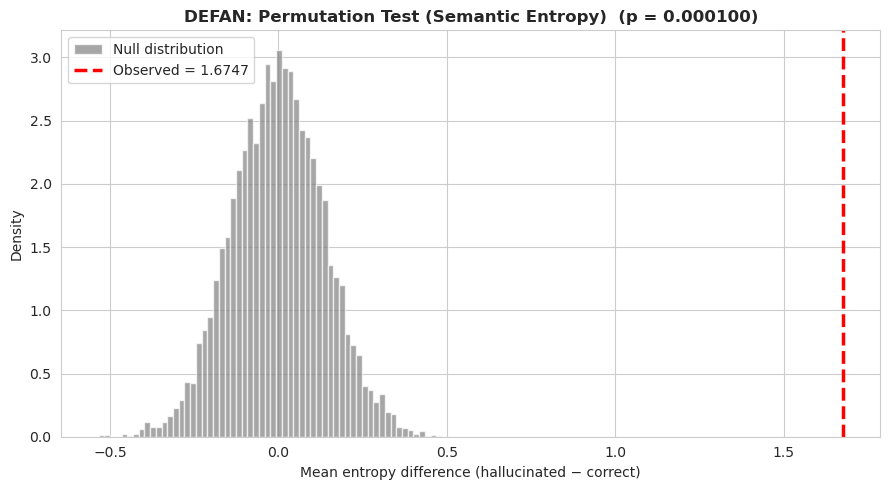

Bootstrap AUC (RF, 6 features, B=2000):
  AUC = 0.8577  95% CI [0.8110, 0.8997]


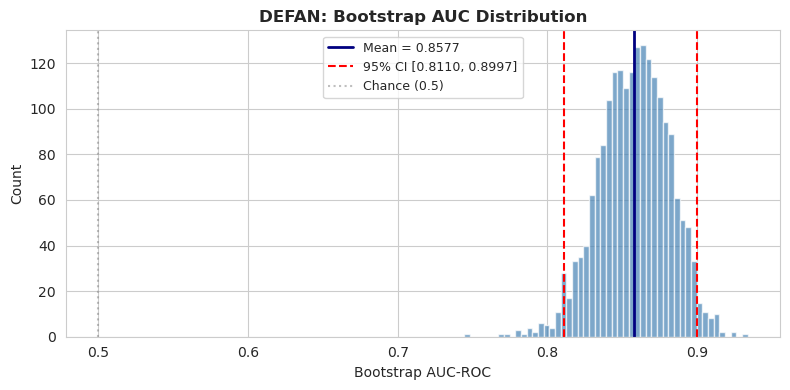


  HALUEVAL
KS tests (Bonferroni alpha=0.0083, 6 tests):
  +  H_sem         D=0.4770  p=1.75e-07  ***
  +  D_cos         D=0.5417  p=1.18e-09  ***
  +  D_cos_var     D=0.5556  p=3.50e-10  ***
  +  D_pair        D=0.5417  p=1.18e-09  ***
  +  K             D=0.4571  p=6.92e-07  ***
  +  sig2_S        D=0.6025  p=4.69e-12  ***


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.4770,1.748237e-07,***,True
1,D_cos,0.5417,1.178612e-09,***,True
2,D_cos_var,0.5556,3.503507e-10,***,True
3,D_pair,0.5417,1.178612e-09,***,True
4,K,0.4571,6.920703e-07,***,True
5,sig2_S,0.6025,4.692467e-12,***,True


Permutation test (10,000 iterations):
  Observed delta = 1.2933
  p-value        = 0.000100


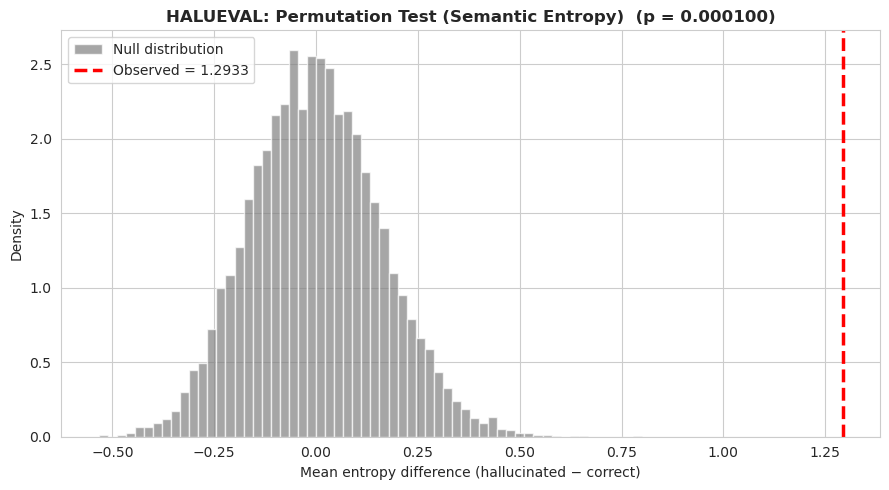

Bootstrap AUC (RF, 6 features, B=2000):
  AUC = 0.8010  95% CI [0.7074, 0.8821]


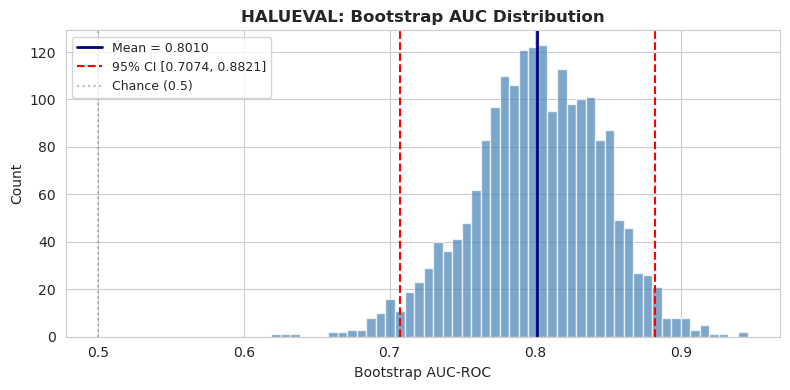


  MMLU
KS tests (Bonferroni alpha=0.0083, 6 tests):
  +  H_sem         D=0.3076  p=1.34e-07  ***
  +  D_cos         D=0.3063  p=1.55e-07  ***
     D_cos_var     D=0.0766  p=6.69e-01  ns
  +  D_pair        D=0.3063  p=1.55e-07  ***
  +  K             D=0.3060  p=1.60e-07  ***
     sig2_S        D=0.0834  p=5.64e-01  ns


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.3076,1.344803e-07,***,True
1,D_cos,0.3063,1.552311e-07,***,True
2,D_cos_var,0.0766,6.689627e-01,ns,False
3,D_pair,0.3063,1.552311e-07,***,True
4,K,0.3060,1.600439e-07,***,True
5,sig2_S,0.0834,5.639895e-01,ns,False


Permutation test (10,000 iterations):
  Observed delta = 0.3847
  p-value        = 0.000100


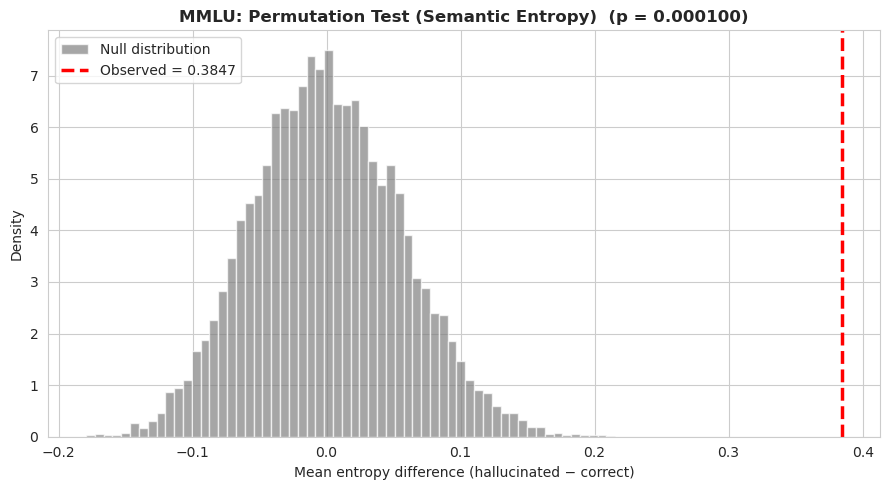

Bootstrap AUC (RF, 6 features, B=2000):
  AUC = 0.6565  95% CI [0.5804, 0.7275]


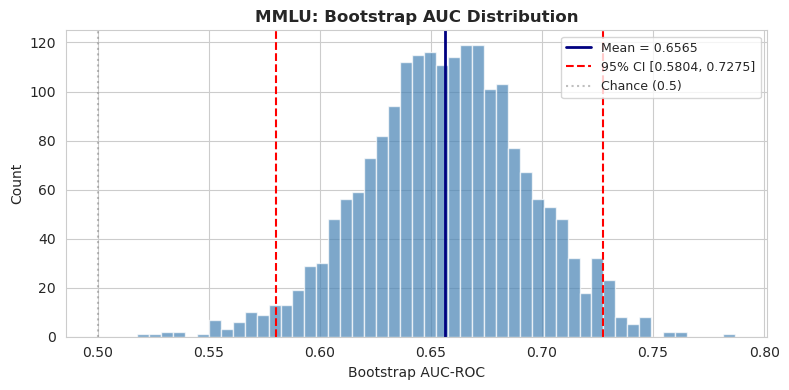


  TRIVIAQA
KS tests (Bonferroni alpha=0.0083, 6 tests):
  +  H_sem         D=0.6640  p=2.32e-51  ***
  +  D_cos         D=0.6811  p=2.66e-54  ***
  +  D_cos_var     D=0.4594  p=1.12e-23  ***
  +  D_pair        D=0.6811  p=2.66e-54  ***
  +  K             D=0.6310  p=5.88e-46  ***
  +  sig2_S        D=0.4731  p=3.86e-25  ***


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.6640,2.322796e-51,***,True
1,D_cos,0.6811,2.658822e-54,***,True
2,D_cos_var,0.4594,1.118056e-23,***,True
3,D_pair,0.6811,2.658822e-54,***,True
4,K,0.6310,5.880889e-46,***,True
5,sig2_S,0.4731,3.863526e-25,***,True


Permutation test (10,000 iterations):
  Observed delta = 2.0118
  p-value        = 0.000100


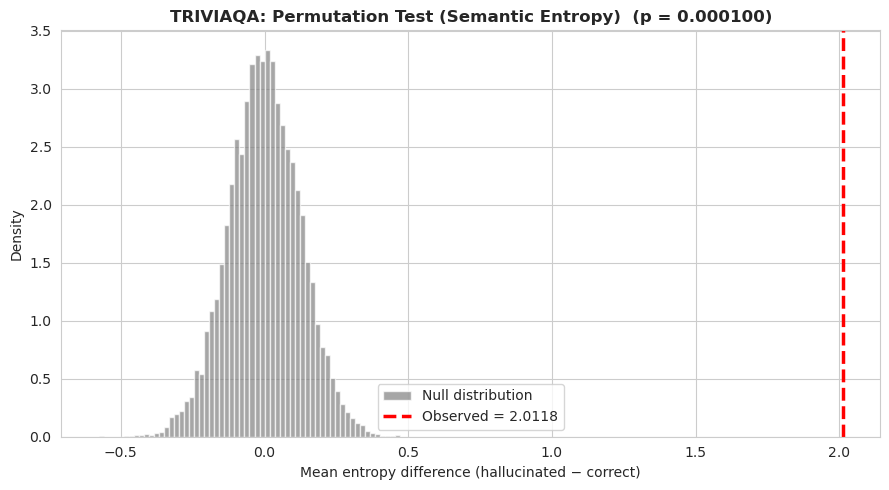

Bootstrap AUC (RF, 6 features, B=2000):
  AUC = 0.9002  95% CI [0.8617, 0.9331]


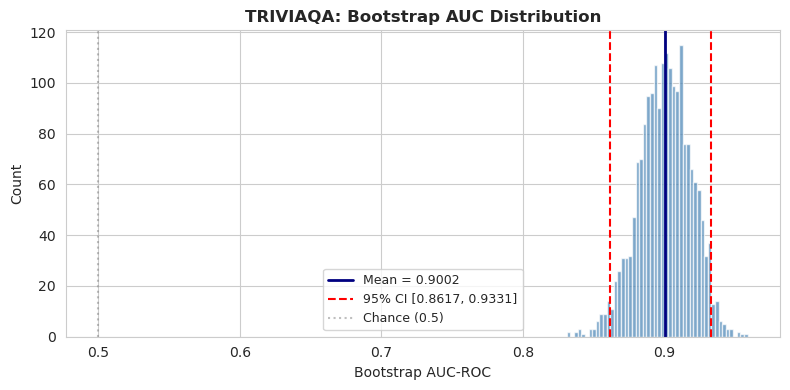


  TRUTHFULQA
KS tests (Bonferroni alpha=0.0083, 6 tests):
  +  H_sem         D=0.3929  p=1.98e-14  ***
  +  D_cos         D=0.3762  p=3.06e-13  ***
     D_cos_var     D=0.1421  p=3.06e-02  *
  +  D_pair        D=0.3762  p=3.06e-13  ***
  +  K             D=0.3687  p=1.01e-12  ***
     sig2_S        D=0.1552  p=1.38e-02  *


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.3929,1.975201e-14,***,True
1,D_cos,0.3762,3.060980e-13,***,True
2,D_cos_var,0.1421,3.061996e-02,*,False
3,D_pair,0.3762,3.060980e-13,***,True
4,K,0.3687,1.012690e-12,***,True
5,sig2_S,0.1552,1.377505e-02,*,False


Permutation test (10,000 iterations):
  Observed delta = 1.1194
  p-value        = 0.000100


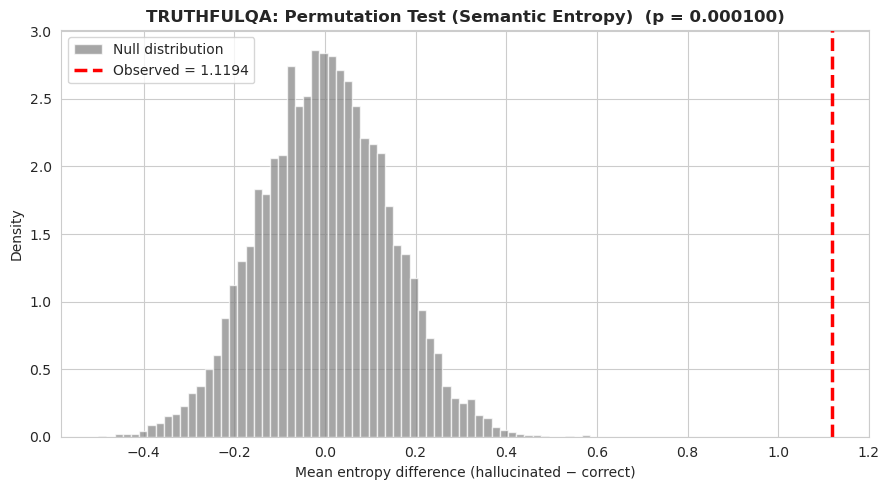

Bootstrap AUC (RF, 6 features, B=2000):
  AUC = 0.7103  95% CI [0.6468, 0.7747]


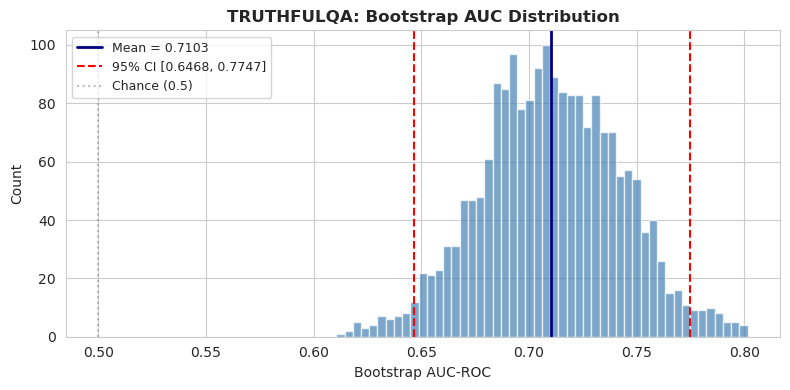


  COMBINED
KS tests (Bonferroni alpha=0.0083, 6 tests):
  +  H_sem         D=0.5927  p=9.80e-202  ***
  +  D_cos         D=0.5603  p=5.87e-179  ***
  +  D_cos_var     D=0.3323  p=8.21e-61  ***
  +  D_pair        D=0.5603  p=5.87e-179  ***
  +  K             D=0.5792  p=5.17e-192  ***
  +  sig2_S        D=0.3382  p=4.84e-63  ***


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.5927,9.803422e-202,***,True
1,D_cos,0.5603,5.868546e-179,***,True
2,D_cos_var,0.3323,8.211381e-61,***,True
3,D_pair,0.5603,5.868546e-179,***,True
4,K,0.5792,5.168830e-192,***,True
5,sig2_S,0.3382,4.839809e-63,***,True


Permutation test (10,000 iterations):
  Observed delta = 1.9928
  p-value        = 0.000100


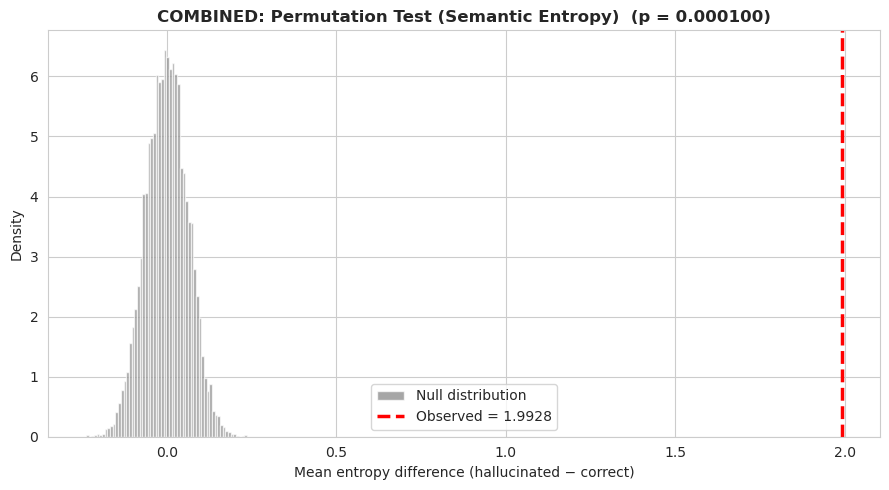

Bootstrap AUC (RF, 6 features, B=2000):
  AUC = 0.8707  95% CI [0.8526, 0.8881]


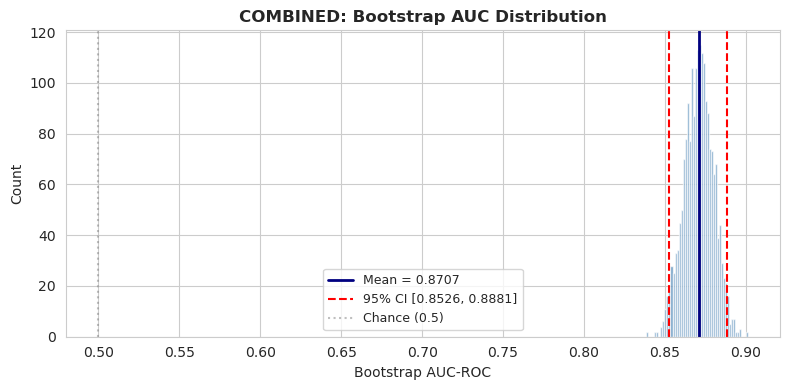

In [4]:
results = {}

all_datasets = {**feat_dfs, 'combined': feat_all}

for name, feat_df in all_datasets.items():
    print(f"\n{'='*60}")
    print(f"  {name.upper()}")
    print(f"{'='*60}")

    # 1. KS tests
    ks_df = run_ks_tests(feat_df)
    ks_df.to_csv(os.path.join(OUTPUT_DIR, f'{name}_ks_global.csv'), index=False)
    display(ks_df)

    # 2. Permutation test
    delta, null_dist, pval = run_permutation_test(
        feat_df, n_permutations=N_PERMUTATIONS, random_seed=SEED)
    fig = plot_permutation_test(
        null_dist, delta, N_PERMUTATIONS, pval,
        title=f'{name.upper()}: Permutation Test (Semantic Entropy)')
    plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_permutation_test.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # 3. Bootstrap AUC
    auc_boot, ci_lo, ci_hi = run_bootstrap_auc(
        feat_df, n_bootstrap=N_BOOTSTRAP, random_seed=SEED)
    fig = plot_bootstrap_auc(auc_boot, ci_lo, ci_hi, dataset_name=name.upper())
    plt.savefig(os.path.join(OUTPUT_DIR, f'{name}_bootstrap_auc.png'), dpi=150, bbox_inches='tight')
    plt.show()

    results[name] = {
        'ks_df': ks_df, 'delta': delta, 'pval': pval,
        'auc_boot': auc_boot, 'ci_lo': ci_lo, 'ci_hi': ci_hi,
    }

**Reading the KS results:** a feature marked Significant (after Bonferroni correction)
has a distribution that clearly differs between hallucinated and correct questions.
$H_{sem}$ (semantic entropy) should show the strongest signal per Farquhar et al. (2024).

**Reading the permutation histogram:** the grey distribution is the null (what we would
see if labels were random). The red dashed line is the observed $\Delta$. If the red line
falls far into the right tail, entropy is a real signal.

**Reading the bootstrap AUC:** the histogram shows the distribution of out-of-bag AUC
across 2,000 resamples. The red dashed lines mark the 95% CI. If the entire CI sits
above 0.5, the classifier reliably outperforms chance.

## Cross-Benchmark Summary

In [5]:
summary_rows = []
for name, r in results.items():
    feat_df = all_datasets[name]
    ks = r['ks_df']
    summary_rows.append({
        'Dataset': name,
        'N_questions': len(feat_df),
        'Hallu_rate': f"{feat_df['label'].mean()*100:.1f}%",
        'KS_sig_features': ks['Significant'].sum(),
        'Best_KS_feature': ks.loc[ks['KS_stat'].idxmax(), 'Feature'],
        'Perm_delta': round(r['delta'], 4),
        'Perm_pval': round(r['pval'], 6),
        'Bootstrap_AUC': f"{r['auc_boot'].mean():.3f} [{r['ci_lo']:.3f}, {r['ci_hi']:.3f}]",
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(os.path.join(OUTPUT_DIR, 'stats_summary.csv'), index=False)
display(df_summary)

,Dataset,N_questions,Hallu_rate,KS_sig_features,Best_KS_feature,Perm_delta,Perm_pval,Bootstrap_AUC
0,defan,500,79.6%,4,H_sem,1.6747,0.0001,"0.858 [0.811, 0.900]"
1,halueval,500,7.2%,6,sig2_S,1.2933,0.0001,"0.801 [0.707, 0.882]"
2,mmlu,500,78.4%,4,H_sem,0.3847,0.0001,"0.657 [0.580, 0.727]"
3,triviaqa,500,41.6%,6,D_cos,2.0118,0.0001,"0.900 [0.862, 0.933]"
4,truthfulqa,500,72.0%,4,H_sem,1.1194,0.0001,"0.710 [0.647, 0.775]"
5,combined,2500,55.8%,6,H_sem,1.9928,0.0001,"0.871 [0.853, 0.888]"
